# Tutorial 07 -- Cavity-Conditioned Qubit Spectroscopy (Number Splitting)

Resolve the qubit line for several fixed cavity Fock states and compare the simulated peaks to the dispersive prediction from `manifold_transition_frequency(...)`.

**Prerequisites.** Tutorials 02, 03, and 06 are recommended first.


## 1. Goal

We will run the same weak qubit spectroscopy scan for `n = 0`, `1`, and `2` cavity Fock states and overlay the predicted line positions.


## 2. Physical Background

In the dispersive regime each cavity photon shifts the qubit line. In the repository's current convention, negative `chi` moves the `n`-resolved qubit lines to lower transition detuning. That makes number splitting a sharp diagnostic of both the physics and the sign conventions.


## 3. Imports


In [1]:
from __future__ import annotations

from functools import partial
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from cqed_sim import (
    AmplifierChain,
    BosonicModeSpec,
    DispersiveCouplingSpec,
    DispersiveReadoutTransmonStorageModel,
    DispersiveTransmonCavityModel,
    DisplacementGate,
    FrameSpec,
    NoiseSpec,
    Pulse,
    PurcellFilter,
    QubitMeasurementSpec,
    ReadoutChain,
    ReadoutResonator,
    RotationGate,
    SidebandDriveSpec,
    SequenceCompiler,
    SimulationConfig,
    StatePreparationSpec,
    TransmonModeSpec,
    UniversalCQEDModel,
    build_displacement_pulse,
    build_rotation_pulse,
    build_sideband_pulse,
    carrier_for_transition_frequency,
    coherent_state,
    compute_energy_spectrum,
    fock_state,
    manifold_transition_frequency,
    measure_qubit,
    prepare_simulation,
    prepare_state,
    pure_dephasing_time_from_t1_t2,
    qubit_state,
    run_rabi,
    run_ramsey,
    run_spectroscopy,
    run_t1,
    run_t2_echo,
    sideband_transition_frequency,
    simulate_batch,
    simulate_sequence,
)
from cqed_sim.plotting import plot_energy_levels
from cqed_sim.pulses import gaussian_envelope, square_envelope
from cqed_sim.sim import (
    cavity_wigner,
    conditioned_bloch_xyz,
    mode_moments,
    qubit_conditioned_mode_moments,
    readout_response_by_qubit_state,
    reduced_cavity_state,
    reduced_qubit_state,
    reduced_storage_state,
    storage_photon_number,
    subsystem_level_population,
    transmon_level_populations,
)
from tutorials.tutorial_support import (
    GHz,
    MHz,
    angular_to_ghz,
    angular_to_hz,
    angular_to_mhz,
    cross_kerr_conditional_phase,
    final_expectation,
    fit_echo_signal,
    fit_exponential_decay,
    fit_lorentzian_peak,
    fit_rabi_vs_amplitude,
    fit_rabi_vs_duration,
    fit_ramsey_signal,
    gaussian_quasistatic_echo_excited_population,
    gaussian_quasistatic_ramsey_excited_population,
    ns,
    ramsey_population,
    resonant_drive_excited_population,
    t1_relaxation_population,
    us,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7.0, 4.2)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 4. Simulation Parameters


In [2]:
fock_levels = [0, 1, 2]
detuning_mhz = np.linspace(-8.0, 2.0, 81)
probe_duration = 1.0 * us
probe_amplitude = MHz(0.08)
dt = 4.0 * ns


## 5. Model Construction


In [3]:
model = DispersiveTransmonCavityModel(
    omega_c=GHz(5.0),
    omega_q=GHz(6.2),
    alpha=0.0,
    chi=MHz(-2.4),
    kerr=0.0,
    n_cav=10,
    n_tr=2,
)
frame = FrameSpec(omega_c_frame=model.omega_c, omega_q_frame=model.omega_q)
predicted_lines_mhz = [angular_to_mhz(manifold_transition_frequency(model, n, frame=frame)) for n in fock_levels]


## 6. Pulse / Sequence Construction


In [4]:
responses = {}
for n in fock_levels:
    trace = []
    for detuning_point_mhz in detuning_mhz:
        probe = Pulse(
            "q",
            t0=0.0,
            duration=probe_duration,
            envelope=square_envelope,
            carrier=carrier_for_transition_frequency(MHz(detuning_point_mhz)),
            amp=probe_amplitude,
            label=f"probe_n{n}",
        )
        compiled = SequenceCompiler(dt=dt).compile([probe], t_end=probe_duration + dt)
        result = simulate_sequence(
            model,
            compiled,
            model.basis_state(0, n),
            {"q": "qubit"},
            config=SimulationConfig(frame=frame, max_step=dt),
        )
        trace.append(final_expectation(result, "P_e"))
    responses[n] = np.asarray(trace, dtype=float)


## 7. Running the Simulation


In [5]:
peak_locations = {n: float(detuning_mhz[int(np.argmax(response))]) for n, response in responses.items()}
print("Predicted peak positions [MHz]:", dict(zip(fock_levels, np.round(predicted_lines_mhz, 4), strict=True)))
print("Observed peak positions [MHz]:", peak_locations)


Predicted peak positions [MHz]: {0: np.float64(0.0), 1: np.float64(-2.4), 2: np.float64(-4.8)}
Observed peak positions [MHz]: {0: 0.0, 1: -2.375, 2: -4.75}


## 8. Visualizing the Results


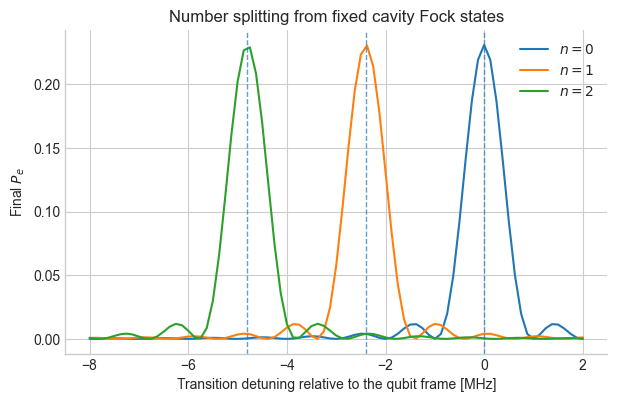

In [6]:
fig, ax = plt.subplots()
for n in fock_levels:
    ax.plot(detuning_mhz, responses[n], label=fr"$n = {n}$")
for n, line_mhz in zip(fock_levels, predicted_lines_mhz, strict=True):
    ax.axvline(line_mhz, linestyle="--", linewidth=1.0, alpha=0.7)
ax.set_xlabel("Transition detuning relative to the qubit frame [MHz]")
ax.set_ylabel(r"Final $P_e$")
ax.set_title("Number splitting from fixed cavity Fock states")
ax.legend()
plt.show()


## 9. Physical Interpretation

The line ordering is the physics check: with negative `chi`, the `n = 2` peak lies to the left of the `n = 1` peak, which lies to the left of the `n = 0` peak. Using `manifold_transition_frequency(...)` keeps the overlay tied to the same sign convention as the Hamiltonian itself.


## 10. Exercises / Next Steps

- Replace the fixed Fock states with a displaced cavity state and think about how the Poisson weights would combine these lines.
- Add a small cavity Kerr to see how higher-`n` manifolds drift away from perfect equal spacing.
- Continue to Tutorial 08 for dressed energies and dispersive frequency bookkeeping.
